# HMM Training Visualization

This notebook inspects the trained reference-specific HMM models in `artifacts/train70_models`. It checks model coverage, summarizes the 70/30 split, and visualizes learned transition and covariance parameters.

In [1]:
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from hmm_alignment.data import list_recordings
from hmm_alignment.dtw import dtw_pseudo_labels
from hmm_alignment.evaluation import frame_error_metrics
from hmm_alignment.features import extract_chroma
from hmm_alignment.hmm import ReferenceHMM

MODEL_DIR = ROOT / "artifacts" / "train70_models"
PIECES = [
    "Chopin_Op017No4",
    "Chopin_Op024No2",
    "Chopin_Op030No2",
    "Chopin_Op063No3",
    "Chopin_Op068No3",
]

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 20)
MODEL_DIR

WindowsPath('c:/Users/nicho/Documents/DSP/E207DTWHMM/artifacts/train70_models')

## Load Model Metadata

In [2]:
pattern = re.compile(r"^(?P<piece>.+)_reference(?P<reference_index>\d+)_train70_hmm\.npz$")
rows = []

for path in sorted(MODEL_DIR.glob("*.npz")):
    match = pattern.match(path.name)
    if match is None:
        continue
    piece = match.group("piece")
    reference_index = int(match.group("reference_index"))
    data = np.load(path, allow_pickle=False)
    reference_features = data["reference_features"]
    jump_probs = data["jump_probs"]
    covariance = data["covariance"]
    rows.append(
        {
            "piece": piece,
            "reference_index": reference_index,
            "path": path,
            "size_mb": path.stat().st_size / 1_000_000,
            "reference_frames": reference_features.shape[0],
            "feature_dim": reference_features.shape[1],
            "jump_sum": jump_probs.sum(),
            "jump_hold": jump_probs[0],
            "jump_advance_1": jump_probs[1],
            "jump_fast": jump_probs[2:].sum(),
            "cov_min": covariance.min(),
            "cov_median": np.median(covariance),
            "cov_max": covariance.max(),
            "covariance_type": str(data["covariance_type"].item()),
            "hard_start": bool(data["hard_start"].item()),
        }
    )

models = pd.DataFrame(rows).sort_values(["piece", "reference_index"]).reset_index(drop=True)
models.head()

,piece,reference_index,path,size_mb,reference_frames,feature_dim,jump_sum,jump_hold,jump_advance_1,jump_fast,cov_min,cov_median,cov_max,covariance_type,hard_start
0,Chopin_Op017No4,0,c:\Users\nicho\Documents\DSP\E207DTWHMM\artifa...,1.602684,17642,12,1.0,0.316285,0.613039,0.070676,0.007030,0.017896,0.045464,diagonal,True
1,Chopin_Op017No4,1,c:\Users\nicho\Documents\DSP\E207DTWHMM\artifa...,1.001957,11024,12,1.0,0.408022,0.532064,0.059914,0.010075,0.017866,0.038772,diagonal,True
2,Chopin_Op017No4,2,c:\Users\nicho\Documents\DSP\E207DTWHMM\artifa...,0.927731,10209,12,1.0,0.470361,0.475262,0.054376,0.009086,0.018941,0.039849,diagonal,True
3,Chopin_Op017No4,3,c:\Users\nicho\Documents\DSP\E207DTWHMM\artifa...,0.921444,10136,12,1.0,0.410968,0.529709,0.059323,0.008545,0.018601,0.032502,diagonal,True
4,Chopin_Op017No4,4,c:\Users\nicho\Documents\DSP\E207DTWHMM\artifa...,1.082744,11915,12,1.0,0.392148,0.545211,0.062641,0.008911,0.018700,0.040907,diagonal,True


In [3]:
split_rows = []
for piece in PIECES:
    recording_count = len(list_recordings(piece))
    train_count = int(recording_count * 0.70)
    model_count = int((models["piece"] == piece).sum())
    split_rows.append(
        {
            "piece": piece,
            "recordings": recording_count,
            "train_query_count": train_count,
            "test_query_count": recording_count - train_count,
            "models_found": model_count,
            "complete": model_count == recording_count,
        }
    )

split_summary = pd.DataFrame(split_rows)
split_summary

,piece,recordings,train_query_count,test_query_count,models_found,complete
0,Chopin_Op017No4,64,44,20,64,True
1,Chopin_Op024No2,64,44,20,64,True
2,Chopin_Op030No2,34,23,11,34,True
3,Chopin_Op063No3,88,61,27,88,True
4,Chopin_Op068No3,51,35,16,51,True


## Coverage And File Sizes

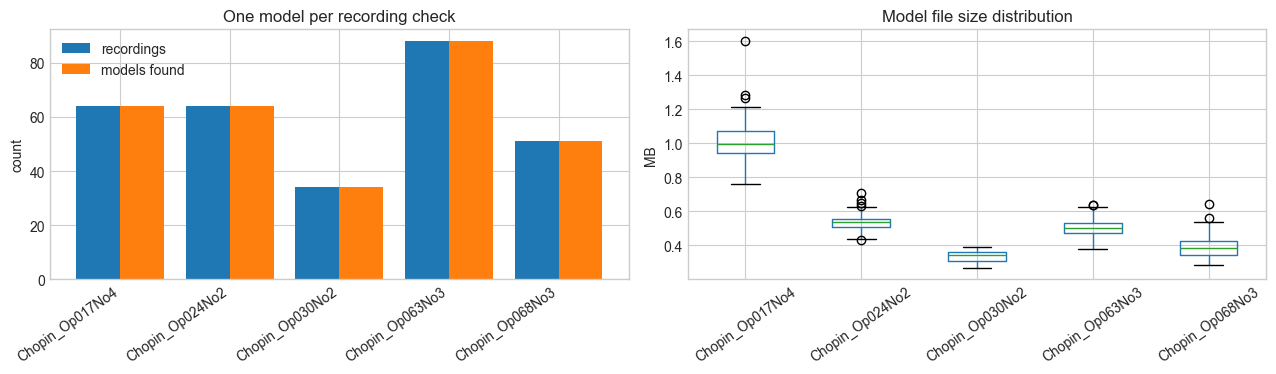

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = np.arange(len(split_summary))
axes[0].bar(x - 0.2, split_summary["recordings"], width=0.4, label="recordings")
axes[0].bar(x + 0.2, split_summary["models_found"], width=0.4, label="models found")
axes[0].set_xticks(x)
axes[0].set_xticklabels(split_summary["piece"], rotation=35, ha="right")
axes[0].set_ylabel("count")
axes[0].set_title("One model per recording check")
axes[0].legend()

models.boxplot(column="size_mb", by="piece", ax=axes[1], rot=35)
axes[1].set_title("Model file size distribution")
axes[1].set_xlabel("")
axes[1].set_ylabel("MB")
fig.suptitle("")
plt.tight_layout()

## Transition Parameters

In [5]:
jump_rows = []
for _, row in models.iterrows():
    data = np.load(row["path"], allow_pickle=False)
    for jump, prob in enumerate(data["jump_probs"]):
        jump_rows.append(
            {
                "piece": row["piece"],
                "reference_index": row["reference_index"],
                "jump": jump,
                "probability": prob,
            }
        )

jumps = pd.DataFrame(jump_rows)
jump_mean = jumps.groupby(["piece", "jump"], as_index=False)["probability"].mean()
jump_mean.pivot(index="piece", columns="jump", values="probability")

jump,0,1,2,3,4
piece,,,,,
Chopin_Op017No4,0.409045,0.535049,0.028729,0.015499,0.011677
Chopin_Op024No2,0.380625,0.541329,0.041951,0.021455,0.014641
Chopin_Op030No2,0.350837,0.577792,0.038053,0.019761,0.013557
Chopin_Op063No3,0.373917,0.560241,0.033702,0.018439,0.013700
Chopin_Op068No3,0.452902,0.496437,0.025678,0.014104,0.010879


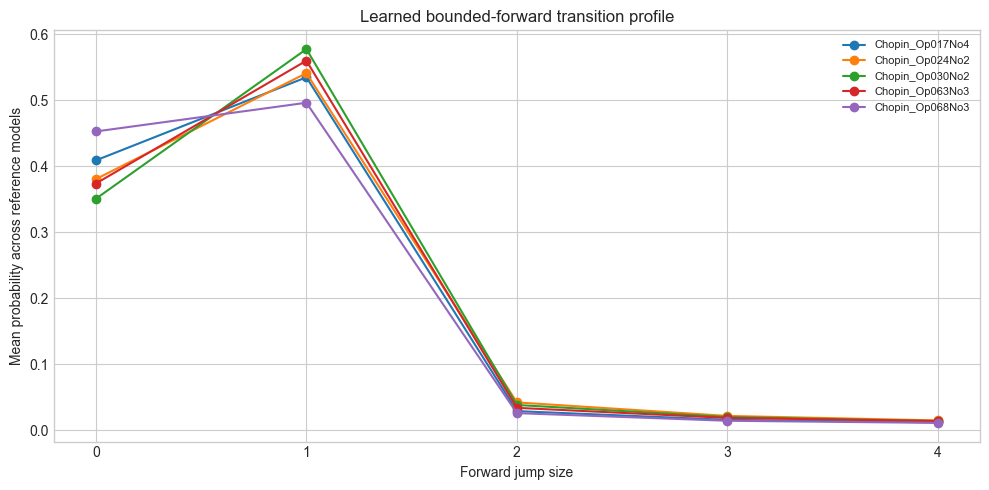

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for piece in PIECES:
    sub = jump_mean[jump_mean["piece"] == piece]
    ax.plot(sub["jump"], sub["probability"], marker="o", label=piece)

ax.set_xlabel("Forward jump size")
ax.set_ylabel("Mean probability across reference models")
ax.set_title("Learned bounded-forward transition profile")
ax.set_xticks(sorted(jumps["jump"].unique()))
ax.legend(fontsize=8)
plt.tight_layout()

## Reference Length And Covariance Diagnostics

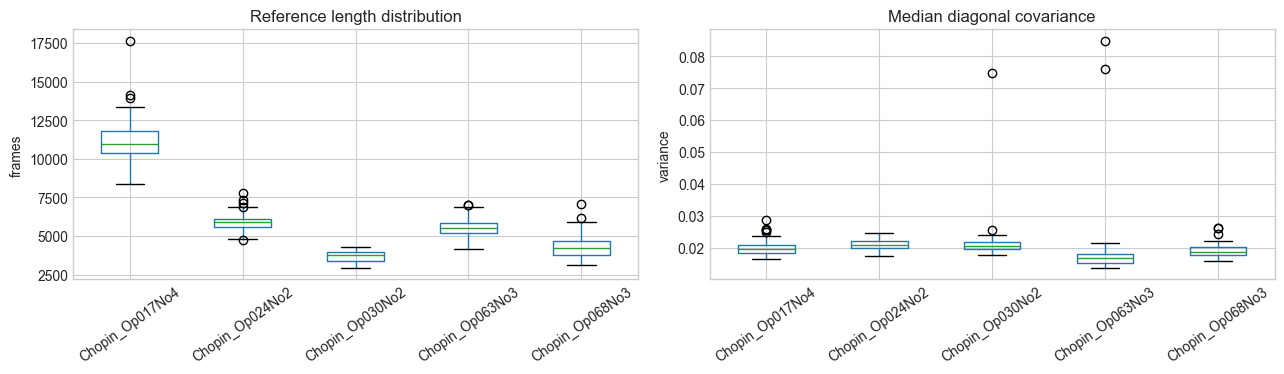

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

models.boxplot(column="reference_frames", by="piece", ax=axes[0], rot=35)
axes[0].set_title("Reference length distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("frames")

models.boxplot(column="cov_median", by="piece", ax=axes[1], rot=35)
axes[1].set_title("Median diagonal covariance")
axes[1].set_xlabel("")
axes[1].set_ylabel("variance")
fig.suptitle("")
plt.tight_layout()

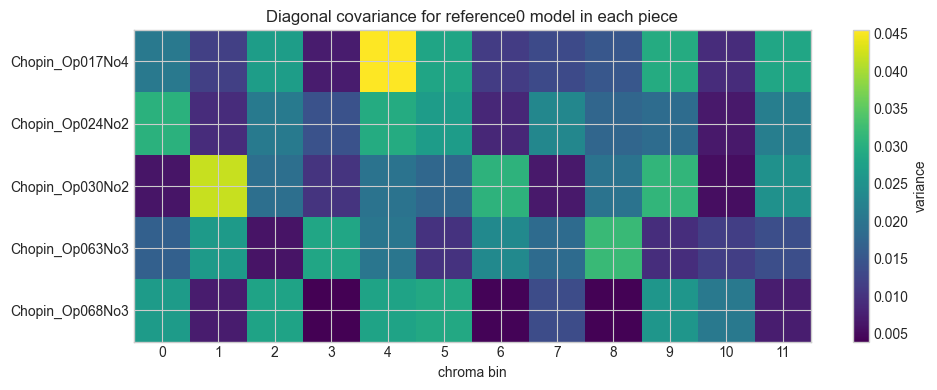

In [8]:
sample_models = models.groupby("piece", as_index=False).first()
cov_matrix = []
labels = []
for _, row in sample_models.iterrows():
    data = np.load(row["path"], allow_pickle=False)
    cov_matrix.append(data["covariance"])
    labels.append(row["piece"])

fig, ax = plt.subplots(figsize=(10, 4))
image = ax.imshow(np.asarray(cov_matrix), aspect="auto", cmap="viridis")
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels)
ax.set_xticks(np.arange(12))
ax.set_xlabel("chroma bin")
ax.set_title("Diagonal covariance for reference0 model in each piece")
fig.colorbar(image, ax=ax, label="variance")
plt.tight_layout()

## Optional Held-Out Alignment Example

This cell evaluates one trained model on the first held-out query for a piece. It can take a little longer because it extracts chroma and computes an offline DTW comparison path.

In [9]:
piece = "Chopin_Op030No2"
reference_index = 0

recordings = list_recordings(piece)
train_count = int(len(recordings) * 0.70)
query_index = train_count

model_path = MODEL_DIR / f"{piece}_reference{reference_index}_train70_hmm.npz"
reference_path = recordings[reference_index]
query_path = recordings[query_index]

model = ReferenceHMM.load(model_path)
reference_features = extract_chroma(reference_path)
query_features = extract_chroma(query_path)

target = dtw_pseudo_labels(query_features, reference_features)
result = model.filter(query_features)
metrics = frame_error_metrics(result.map_path, target)
metrics

FrameErrorMetrics(mean_abs_error=7.9629057187017, median_abs_error=2.0, within_1_frame=0.4846986089644513, within_5_frames=0.6741885625965996, within_10_frames=0.7746522411128285)

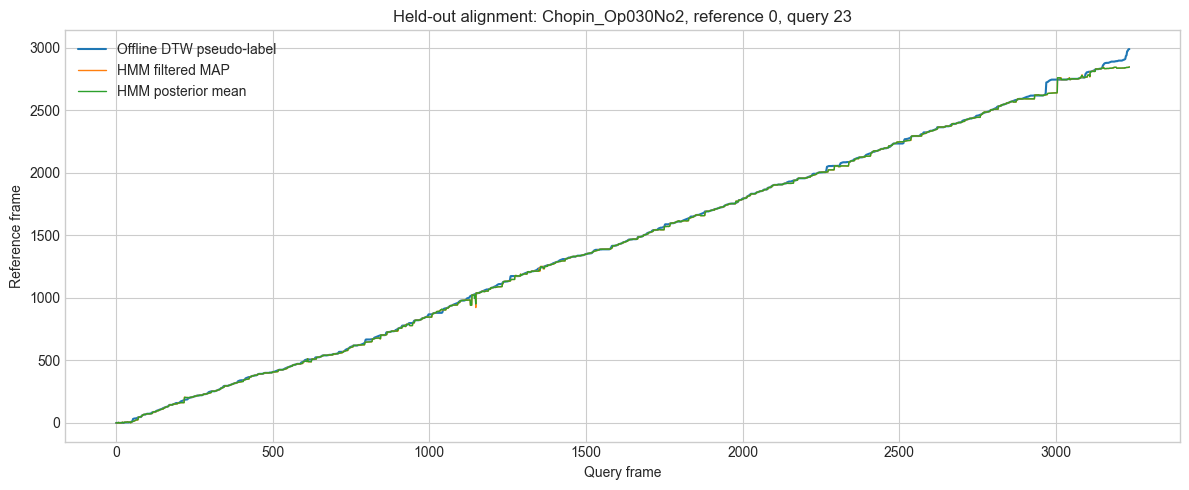

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(target, label="Offline DTW pseudo-label", linewidth=1.5)
ax.plot(result.map_path, label="HMM filtered MAP", linewidth=1.0)
ax.plot(result.mean_path, label="HMM posterior mean", linewidth=1.0)
ax.set_title(f"Held-out alignment: {piece}, reference {reference_index}, query {query_index}")
ax.set_xlabel("Query frame")
ax.set_ylabel("Reference frame")
ax.legend()
plt.tight_layout()